In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, multilabel_confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import timm
from transformers import ViTImageProcessor, ViTForImageClassification
import warnings
warnings.filterwarnings('ignore')
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images", "new_images")

# Disease labels for multi-label classification
DISEASE_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

NUM_CLASSES = len(DISEASE_LABELS)
print(f"Number of disease classes: {NUM_CLASSES}")
print(f"Disease labels: {DISEASE_LABELS}")

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
IMAGE_SIZE = 224

Number of disease classes: 14
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [4]:
# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df[['Path'] + DISEASE_LABELS].copy()

print(f"\nTotal samples: {len(df)}")
print(f"Dataset shape: {df.shape}")

# Get labels as numpy array for stratification
y = df[DISEASE_LABELS].values

# Stratified split for multi-label (80/20 split)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(msss.split(df, y))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print(f"\nTraining samples: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation samples: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Train/Val ratio: {len(train_df)/len(val_df):.2f}")

# Verify each disease is proportionally split
print(f"\nClass distribution verification:")
for label in DISEASE_LABELS:
    train_count = train_df[label].sum()
    val_count = val_df[label].sum()
    total = train_count + val_count
    if total > 0:
        print(f"{label:20s}: Train={train_count:5d} ({train_count/total*100:5.1f}%), "
              f"Val={val_count:4d} ({val_count/total*100:5.1f}%)")

# Verify "No Finding" distribution (if applicable)
train_no_finding = (train_df[DISEASE_LABELS].sum(axis=1) == 0).sum()
val_no_finding = (val_df[DISEASE_LABELS].sum(axis=1) == 0).sum()
total_no_finding = train_no_finding + val_no_finding

if total_no_finding > 0:
    print(f"\n'No Finding' distribution:")
    print(f"No Finding          : Train={train_no_finding:5d} ({train_no_finding/total_no_finding*100:5.1f}%), "
          f"Val={val_no_finding:4d} ({val_no_finding/total_no_finding*100:5.1f}%)")


Total samples: 51382
Dataset shape: (51382, 15)

Training samples: 41105 (80.0%)
Validation samples: 10277 (20.0%)
Train/Val ratio: 4.00

Class distribution verification:
Atelectasis         : Train= 3830 ( 80.0%), Val= 958 ( 20.0%)
Cardiomegaly        : Train= 3703 ( 80.0%), Val= 926 ( 20.0%)
Consolidation       : Train= 3585 ( 80.0%), Val= 896 ( 20.0%)
Edema               : Train= 3643 ( 80.0%), Val= 911 ( 20.0%)
Effusion            : Train= 4000 ( 80.0%), Val=1000 ( 20.0%)
Emphysema           : Train= 3574 ( 80.0%), Val= 893 ( 20.0%)
Fibrosis            : Train= 4031 ( 80.0%), Val=1008 ( 20.0%)
Hernia              : Train= 4472 ( 80.0%), Val=1118 ( 20.0%)
Infiltration        : Train= 4592 ( 80.0%), Val=1148 ( 20.0%)
Mass                : Train= 4451 ( 80.0%), Val=1113 ( 20.0%)
Nodule              : Train= 4507 ( 80.0%), Val=1127 ( 20.0%)
Pleural_Thickening  : Train= 3865 ( 80.0%), Val= 966 ( 20.0%)
Pneumonia           : Train= 4884 ( 80.0%), Val=1221 ( 20.0%)
Pneumothorax        : 

In [5]:
# ============================================================================
# IMPORT CUSTOM DATASET CLASS
# ============================================================================
from dataset_handler import NIHChestXrayDataset

print("NIHChestXrayDataset class imported successfully.")

NIHChestXrayDataset class imported successfully.


In [ ]:
# ============================================================================
# DATA AUGMENTATION AND TRANSFORMS (Conservative for CXR)
# ============================================================================

# Training transforms with MINIMAL augmentation (CXR-sensitive)
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Safe for CXR
    transforms.RandomRotation(degrees=5),    # Reduced to ±5° (was 10°)
    # Removed ColorJitter - CXR intensity values are diagnostically important
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Test transforms (identical to validation)
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

In [7]:
# ============================================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================================

# Create datasets
train_dataset = NIHChestXrayDataset(
    train_df, IMAGE_DIR, DISEASE_LABELS, transform=train_transforms
)
val_dataset = NIHChestXrayDataset(
    val_df, IMAGE_DIR, DISEASE_LABELS, transform=val_transforms
)

# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True
)

print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")



Number of training batches: 1285
Number of validation batches: 322


In [8]:
# ============================================================================
# MODEL DEFINITION
# ============================================================================

class ViTForMultiLabelClassification(nn.Module):
    """Vision Transformer for multi-label classification"""
    
    def __init__(self, num_classes, pretrained=True):
        super(ViTForMultiLabelClassification, self).__init__()
        
        # Load pretrained ViT model using timm
        self.vit = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=0  # Remove classification head
        )
        
        # Get the feature dimension
        self.feature_dim = self.vit.num_features
        
        # Custom classification head for multi-label
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        # Extract features
        features = self.vit(x)
        
        # Classification
        logits = self.classifier(features)
        
        return logits

# Initialize model
model = ViTForMultiLabelClassification(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

print(f"\nModel architecture:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model architecture:
Total parameters: 21,869,966
Trainable parameters: 21,869,966


In [9]:
# ============================================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================================

# Binary Cross Entropy with Logits Loss (handles multi-label)
criterion = nn.BCEWithLogitsLoss()

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=NUM_EPOCHS
)

In [10]:
# ============================================================================
# TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        
        # Store predictions and labels
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            
            # Store predictions and labels
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def compute_metrics(labels, predictions, threshold=0.5):
    """Compute evaluation metrics"""
    metrics = {}
    
    # ROC AUC (per class and mean)
    try:
        auc_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:  # Check if both classes present
                auc = roc_auc_score(labels[:, i], predictions[:, i])
                auc_scores.append(auc)
        metrics['auc_mean'] = np.mean(auc_scores) if auc_scores else 0.0
    except:
        metrics['auc_mean'] = 0.0
    
    # Average Precision (per class and mean)
    try:
        ap_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:
                ap = average_precision_score(labels[:, i], predictions[:, i])
                ap_scores.append(ap)
        metrics['ap_mean'] = np.mean(ap_scores) if ap_scores else 0.0
    except:
        metrics['ap_mean'] = 0.0
    
    # Binary predictions for accuracy
    binary_preds = (predictions >= threshold).astype(int)
    
    # Accuracy
    metrics['accuracy'] = np.mean(binary_preds == labels)
    
    return metrics

In [ ]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_auc': [],
    'val_auc': [],
    'train_ap': [],
    'val_ap': [],
    'train_acc': [],
    'val_acc': []
}

best_val_auc = 0.0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Train
    train_loss, train_preds, train_labels = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    train_metrics = compute_metrics(train_labels, train_preds)
    
    # Validate
    val_loss, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, device
    )
    val_metrics = compute_metrics(val_labels, val_preds)
    
    # Update learning rate
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_metrics['auc_mean'])
    history['val_auc'].append(val_metrics['auc_mean'])
    history['train_ap'].append(train_metrics['ap_mean'])
    history['val_ap'].append(val_metrics['ap_mean'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    
    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train AUC: {train_metrics['auc_mean']:.4f} | Val AUC: {val_metrics['auc_mean']:.4f}")
    print(f"Train AP: {train_metrics['ap_mean']:.4f} | Val AP: {val_metrics['ap_mean']:.4f}")
    print(f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_met  rics['accuracy']:.4f}")
    
    # Save best model
    if val_metrics['auc_mean'] > best_val_auc:
        best_val_auc = val_metrics['auc_mean']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': best_val_auc,
        }, 'best_vit_model.pth')
        print(f"✓ Saved best model (Val AUC: {best_val_auc:.4f})")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETED")
print(f"Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch}")
print(f"{'='*70}")


STARTING TRAINING

Epoch 1/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [02:03<00:00,  2.61it/s, loss=0.349]



Train Loss: 0.2877 | Val Loss: 0.2514
Train AUC: 0.7095 | Val AUC: 0.8036
Train AP: 0.2701 | Val AP: 0.4175
Train Acc: 0.9047 | Val Acc: 0.9122
✓ Saved best model (Val AUC: 0.8036)

Epoch 2/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [02:06<00:00,  2.55it/s, loss=0.303] 



Train Loss: 0.2462 | Val Loss: 0.2302
Train AUC: 0.8013 | Val AUC: 0.8390
Train AP: 0.4228 | Val AP: 0.4927
Train Acc: 0.9144 | Val Acc: 0.9184
✓ Saved best model (Val AUC: 0.8390)

Epoch 3/10
----------------------------------------------------------------------


...


Train Loss: 0.1698 | Val Loss: 0.1931
Train AUC: 0.9124 | Val AUC: 0.8841
Train AP: 0.6755 | Val AP: 0.6110
Train Acc: 0.9375 | Val Acc: 0.9310
✓ Saved best model (Val AUC: 0.8841)

Epoch 9/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [01:53<00:00,  2.84it/s, loss=0.215]  



Train Loss: 0.1648 | Val Loss: 0.1920
Train AUC: 0.9171 | Val AUC: 0.8856
Train AP: 0.6906 | Val AP: 0.6124
Train Acc: 0.9398 | Val Acc: 0.9307
✓ Saved best model (Val AUC: 0.8856)

Epoch 10/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [01:56<00:00,  2.77it/s, loss=0.222]  



Train Loss: 0.1615 | Val Loss: 0.1920
Train AUC: 0.9205 | Val AUC: 0.8856
Train AP: 0.7013 | Val AP: 0.6135
Train Acc: 0.9408 | Val Acc: 0.9309
✓ Saved best model (Val AUC: 0.8856)

TRAINING COMPLETED
Best Val AUC: 0.8856 at epoch 10


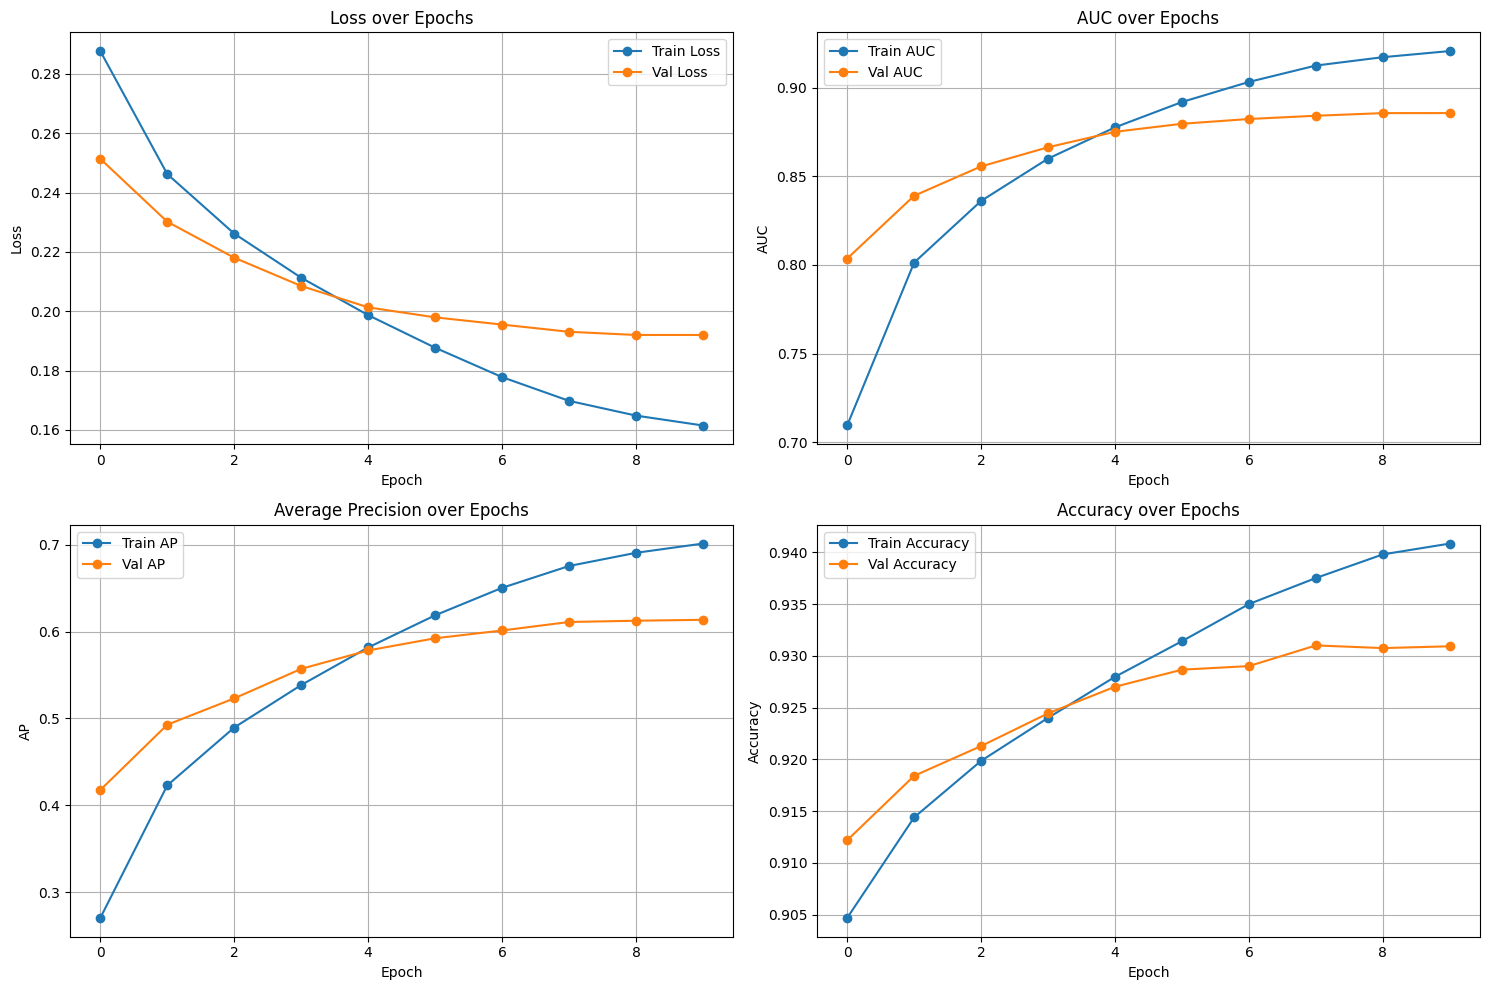


✓ Training history plot saved as 'training_history.png'


In [12]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history['train_auc'], label='Train AUC', marker='o')
axes[0, 1].plot(history['val_auc'], label='Val AUC', marker='o')
axes[0, 1].set_title('AUC over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Average Precision
axes[1, 0].plot(history['train_ap'], label='Train AP', marker='o')
axes[1, 0].plot(history['val_ap'], label='Val AP', marker='o')
axes[1, 0].set_title('Average Precision over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AP')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1, 1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1, 1].set_title('Accuracy over Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training history plot saved as 'training_history.png'")

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score

# ============================================================================
# EVALUATE ON VALIDATION SET WITH BEST MODEL
# ============================================================================

print("\n" + "="*70)
print("FINAL EVALUATION ON BEST MODEL")
print("="*70)

# Load best model
checkpoint = torch.load('best_vit_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
val_loss, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)
val_metrics = compute_metrics(val_labels, val_preds)

# Convert predictions to binary (threshold = 0.5)
val_preds_binary = (val_preds >= 0.5).astype(int)

print(f"\nOverall Metrics:")
print("-" * 70)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation AUC: {val_metrics['auc_mean']:.4f}")
print(f"Validation AP: {val_metrics['ap_mean']:.4f}")
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")

# F1 Scores
f1_micro = f1_score(val_labels, val_preds_binary, average='micro')
f1_macro = f1_score(val_labels, val_preds_binary, average='macro')
f1_weighted = f1_score(val_labels, val_preds_binary, average='weighted')

print(f"\nF1 Scores:")
print(f"  F1 (Micro):    {f1_micro:.4f}")
print(f"  F1 (Macro):    {f1_macro:.4f}")
print(f"  F1 (Weighted): {f1_weighted:.4f}")

# Precision and Recall
precision_micro = precision_score(val_labels, val_preds_binary, average='micro')
precision_macro = precision_score(val_labels, val_preds_binary, average='macro')
recall_micro = recall_score(val_labels, val_preds_binary, average='micro')
recall_macro = recall_score(val_labels, val_preds_binary, average='macro')

print(f"\nPrecision & Recall:")
print(f"  Precision (Micro): {precision_micro:.4f}")
print(f"  Precision (Macro): {precision_macro:.4f}")
print(f"  Recall (Micro):    {recall_micro:.4f}")
print(f"  Recall (Macro):    {recall_macro:.4f}")

# Per-class metrics
print(f"\n{'='*70}")
print("PER-CLASS METRICS")
print("="*70)
print(f"{'Disease':<25} {'AUC':<8} {'AP':<8} {'F1':<8} {'Prec':<8} {'Recall':<8}")
print("-" * 70)

for i, label in enumerate(DISEASE_LABELS):
    if len(np.unique(val_labels[:, i])) > 1:
        auc = roc_auc_score(val_labels[:, i], val_preds[:, i])
        ap = average_precision_score(val_labels[:, i], val_preds[:, i])
        f1 = f1_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        precision = precision_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        recall = recall_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        
        print(f"{label:<25} {auc:<8.4f} {ap:<8.4f} {f1:<8.4f} {precision:<8.4f} {recall:<8.4f}")
    else:
        print(f"{label:<25} {'N/A':<8} {'N/A':<8} {'N/A':<8} {'N/A':<8} {'N/A':<8}")

print("\n" + "="*70)
print("✓ Training and evaluation complete!")
print("="*70)


FINAL EVALUATION ON BEST MODEL
Loaded best model from epoch 10


Validation: 100%|██████████| 322/322 [01:32<00:00,  3.50it/s, loss=0.222]  



Overall Metrics:
----------------------------------------------------------------------
Validation Loss: 0.1920
Validation AUC: 0.8856
Validation AP: 0.6135
Validation Accuracy: 0.9309

F1 Scores:
  F1 (Micro):    0.5538
  F1 (Macro):    0.5150
  F1 (Weighted): 0.5159

Precision & Recall:
  Precision (Micro): 0.7704
  Precision (Macro): 0.7362
  Recall (Micro):    0.4323
  Recall (Macro):    0.4302

PER-CLASS METRICS
Disease                   AUC      AP       F1       Prec     Recall  
----------------------------------------------------------------------
Atelectasis               0.8262   0.4191   0.2923   0.6006   0.1931  
Cardiomegaly              0.9534   0.7789   0.6987   0.8135   0.6123  
Consolidation             0.8199   0.3981   0.2591   0.6875   0.1596  
Edema                     0.9629   0.8172   0.7141   0.8008   0.6443  
Effusion                  0.8556   0.5404   0.4425   0.6756   0.3290  
Emphysema                 0.9372   0.7369   0.6556   0.8023   0.5543  
Fibrosis  